In [1]:
using Pkg
    Pkg.activate(".")
using PyPlot, PsfUnmixing, LinearAlgebra

  Activating project at `~/PsfUnmixing`


In [2]:
function residual(θ, η, x_obs, dictionary, xgrid) 
    @assert length(dictionary) == length(θ) # should be p
    @assert sum(length.(dictionary)) == length(η) #should be p*d
    @assert length(x_obs) == length(xgrid) # just to be same
    A = multi_block(k_0, θ, dictionary, xgrid) # we don change the xgrid or the kernel
    return x_obs - A * η
end

residual (generic function with 1 method)

In [3]:
"""
    sample_theta_sphere(θ_star, R; nφ=50, nθ=50)

Returns (Θx, Θy, Θz, Θ) where Θ[i,j] is the θ-vector.
"""
function sample_theta_sphere(θ_star, R; nφ=50, nθ=50)
    φs = range(0, π; length=nφ)
    θs = range(0, 2π; length=nθ)

    Θ = Array{Vector{Float64}}(undef, nφ, nθ)

    for i in 1:nφ, j in 1:nθ
        φ, θ = φs[i], θs[j]
        Θ[i,j] = θ_star .+ R .* [
            sin(φ)*cos(θ),
            sin(φ)*sin(θ),
            cos(φ)
        ]
    end

    Θx = [Θ[i,j][1] for i in 1:nφ, j in 1:nθ]
    Θy = [Θ[i,j][2] for i in 1:nφ, j in 1:nθ]
    Θz = [Θ[i,j][3] for i in 1:nφ, j in 1:nθ]

    return Θx, Θy, Θz, Θ
end


sample_theta_sphere

In [4]:
"""
    map_theta_to_eta(Θ, x_obs, dictionary, xgrid)

Maps Θ[i,j] → η[i,j] = G(θ)† x_obs
"""
function map_theta_to_eta(Θ, x_obs, dictionary, xgrid)
    nφ, nθ = size(Θ)
    Η = Array{Vector{Float64}}(undef, nφ, nθ)

    for i in 1:nφ, j in 1:nθ
        θ = Θ[i,j]
        Gθ = multi_block(k_0, θ, dictionary, xgrid)
        Η[i,j] = Gθ \ x_obs
    end

    Ηx = [Η[i,j][1] for i in 1:nφ, j in 1:nθ]
    Ηy = [Η[i,j][2] for i in 1:nφ, j in 1:nθ]
    Ηz = [Η[i,j][3] for i in 1:nφ, j in 1:nθ]

    return Ηx, Ηy, Ηz, Η
end


map_theta_to_eta

In [5]:
"""
    compute_loss_on_sphere(Θ, Η, x_obs, dictionary, xgrid)

Returns loss array L
"""
function compute_loss_on_sphere(Θ, Η, x_obs, dictionary, xgrid)
    nφ, nθ = size(Θ)
    L = zeros(nφ, nθ)

    for i in 1:nφ, j in 1:nθ
        r = residual(Θ[i,j], Η[i,j], x_obs, dictionary, xgrid)
        L[i,j] = sum(abs2, r)
    end

    return L
end


compute_loss_on_sphere

In [6]:
function plot_theta_eta_spheres_pyplot(
    Θx, Θy, Θz,
    Ηx, Ηy, Ηz,
    L,
    filename;
    view1 = (30,60),
    view2 = (30,60),
    vmin = nothing,
    vmax = nothing,
)

    # --- LaTeX fonts ---
    PyPlot.rc("text", usetex = true)
    PyPlot.rc("font", family = "serif", size = 20)

    # --- FIXED normalization (shared across figures) ---
    if vmin === nothing || vmax === nothing
        vmin = minimum(L)
        vmax = maximum(L)
    end
    denom = vmax - vmin
    denom = denom == 0 ? 1.0 : denom

    norm = PyPlot.matplotlib.colors.Normalize(vmin = vmin, vmax = vmax)
    cmap = PyPlot.cm.plasma

    fig = PyPlot.figure(figsize = (20, 10))

    # --- styling helper ---
    function beautify_3d_axis!(ax)
        ax.grid(false)
        ax.xaxis._axinfo["grid"]["linewidth"] = 0
        ax.yaxis._axinfo["grid"]["linewidth"] = 0
        ax.zaxis._axinfo["grid"]["linewidth"] = 0

        ax.xaxis.pane.set_facecolor((1,1,1,0))
        ax.yaxis.pane.set_facecolor((1,1,1,0))
        ax.zaxis.pane.set_facecolor((1,1,1,0))

        ax.xaxis.pane.set_edgecolor((1,1,1,0))
        ax.yaxis.pane.set_edgecolor((1,1,1,0))
        ax.zaxis.pane.set_edgecolor((1,1,1,0))

        try
            ax.set_box_aspect((1,1,1))
        catch
        end
    end

    m, n = size(Θx)

    # --- θ-space ---
    ax1 = fig.add_subplot(1,2,1, projection="3d")
    ax1.plot_surface(
        Θx, Θy, Θz;
        facecolors = cmap(norm(L)),
        linewidth = 0,
        edgecolor = "none",
        antialiased = false,
        shade = false,
        rcount = m,
        ccount = n,
    )
    ax1.view_init(elev=view1[1], azim=view1[2])
    beautify_3d_axis!(ax1)
    ax1.set_axis_off()

    # --- η-space ---
    ax2 = fig.add_subplot(1,2,2, projection="3d")
    ax2.plot_surface(
        Ηx, Ηy, Ηz;
        facecolors = cmap(norm(L)),
        linewidth = 0,
        edgecolor = "none",
        antialiased = false,
        shade = false,
        rcount = m,
        ccount = n,
    )
    ax2.view_init(elev=view2[1], azim=view2[2])
    beautify_3d_axis!(ax2)
    ax2.set_axis_off()

    # --- SHARED colorbar ---
    mappable = PyPlot.cm.ScalarMappable(cmap = cmap, norm = norm)
    mappable.set_array(L)

    cbar = fig.colorbar(
        mappable,
        ax = [ax1, ax2],
        fraction = 0.035,
        pad = 0.02,
        shrink = 0.85,
    )
    cbar.ax.tick_params(labelsize = 20)

    fig.subplots_adjust(wspace = 0, right = 0.85)
    fig.savefig("figures/" * filename, bbox_inches = "tight", pad_inches = 0.02)
    return fig
end



plot_theta_eta_spheres_pyplot (generic function with 1 method)

In [7]:
u = 2

θ_min = 1e-3
θ_max = 1e-2

k_0(θ, t) = laplace_0(θ, t, u)
# k_0(θ, t) = @. max(0.0, 1.0 - abs(t)/θ)
p = 3
d = 1

T = 1.0
Δ = 2e-2

N = 1_100

xgrid = range(-T, T, N)

θ_star = 0.5 * (θ_min + θ_max) * ones(p) # always midpoint
η_star = ones(p*d)
η_star = η_star/norm(η_star, 2);

R = 0.5 * (θ_max - θ_min);

In [8]:
manual_dict = [[-T + 1e-5], [-T + Δ + 1e-5], [-T + 2Δ + 1e-5]];

In [9]:
x_obs = multi_block(k_0, θ_star, manual_dict, xgrid) * η_star;

In [10]:
Θx, Θy, Θz, Θ = sample_theta_sphere(θ_star, 0.5*(θ_max - θ_min); nφ=100, nθ=100)
Ηx, Ηy, Ηz, Η = map_theta_to_eta(Θ, x_obs, manual_dict, xgrid)
L = compute_loss_on_sphere(Θ, Η, x_obs, manual_dict, xgrid);

In [11]:
using Random, Statistics

function add_awgn(x_obs::AbstractVector, snr_db::Real)
    # Signal power
    signal_power = mean(abs2, x_obs)

    # Convert SNR from dB to linear scale
    snr_linear = 10.0^(snr_db / 10)

    # Noise power and standard deviation
    noise_power = signal_power / snr_linear
    noise_std = sqrt(noise_power)

    # Add white Gaussian noise
    noise = noise_std * randn(length(x_obs))
    return x_obs .+ noise
end


add_awgn (generic function with 1 method)

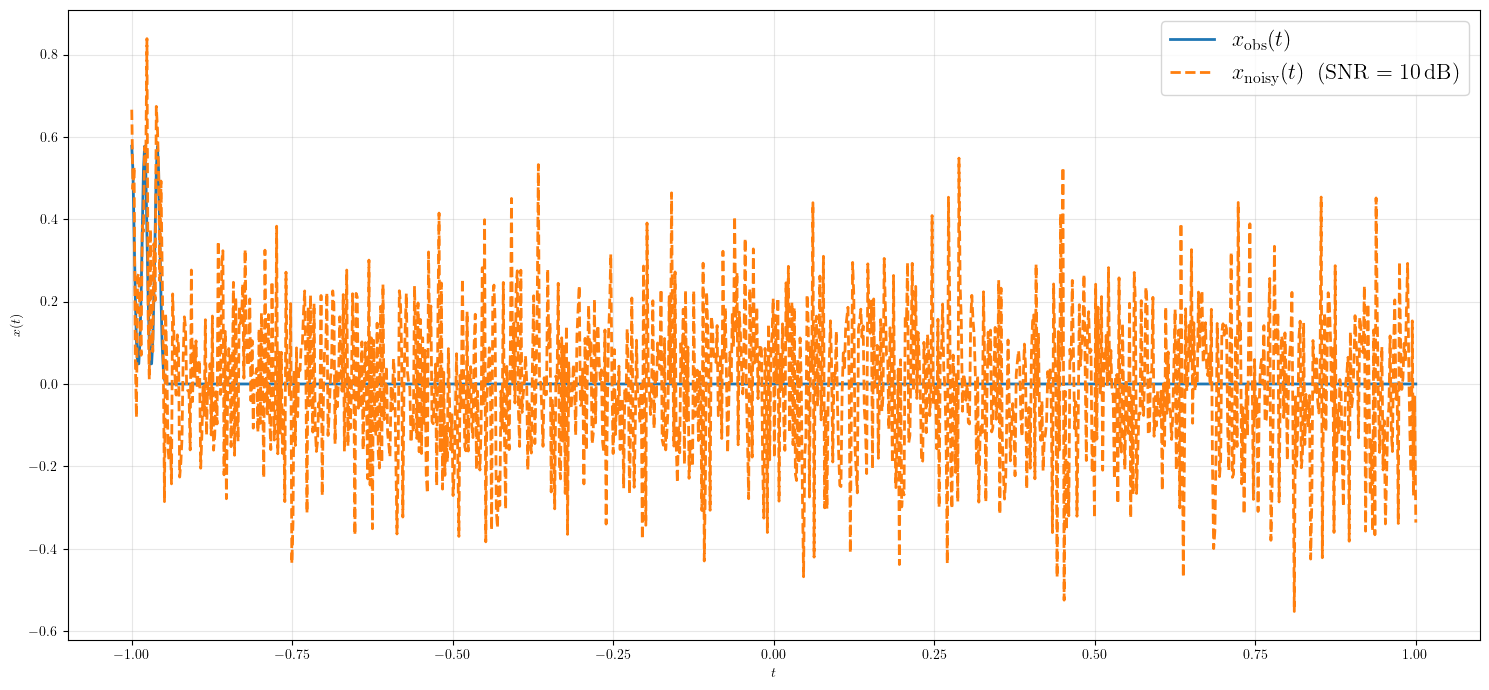

In [12]:
using PyPlot

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")

fig = PyPlot.figure(figsize=(15, 7))
ax  = fig.add_subplot(1,1,1)

# clean signal
ax.plot(
    collect(xgrid),
    x_obs,
    linewidth=2,
    label=L"$x_{\mathrm{obs}}(t)$"
)

# noisy signal
dB = -10.0
x_noisy = add_awgn(x_obs, dB)

ax.plot(
    collect(xgrid),
    x_noisy,
    linewidth=2,
    linestyle="--",
    label=L"$x_{\mathrm{noisy}}(t)\;\;(\mathrm{SNR}=10\,\mathrm{dB})$"
)

# labels (set ONCE)
ax.set_xlabel(L"$t$")
ax.set_ylabel(L"$x(t)$")

# grid + legend
ax.grid(true, alpha=0.3)
ax.legend(fontsize=16)

PyPlot.tight_layout()

fig

In [13]:
Ηx_noisy, Ηy_noisy, Ηz_noisy, Η_noisy = map_theta_to_eta(Θ, x_noisy, manual_dict, xgrid)
L_noisy = compute_loss_on_sphere(Θ, Η_noisy, x_noisy, manual_dict, xgrid);

In [14]:
normalizer = max(norm(L, Inf), norm(L_noisy, Inf))

35.168982407431976

In [15]:
using StatsBase

"""
Match the histogram of L_src to L_ref (quantile mapping).
"""
function match_histogram(L_src, L_ref)
    src = vec(L_src)
    ref = vec(L_ref)

    # empirical CDF of source
    ecdf_src = ecdf(src)

    # quantiles of reference
    qs = sort(ref)

    # map each value
    mapped = similar(src)
    for i in eachindex(src)
        p = ecdf_src(src[i])                 # percentile
        idx = clamp(Int(round(p*(length(qs)-1)))+1, 1, length(qs))
        mapped[i] = qs[idx]
    end

    return reshape(mapped, size(L_src))
end


match_histogram

In [16]:
L_matched = match_histogram(L, L_noisy);

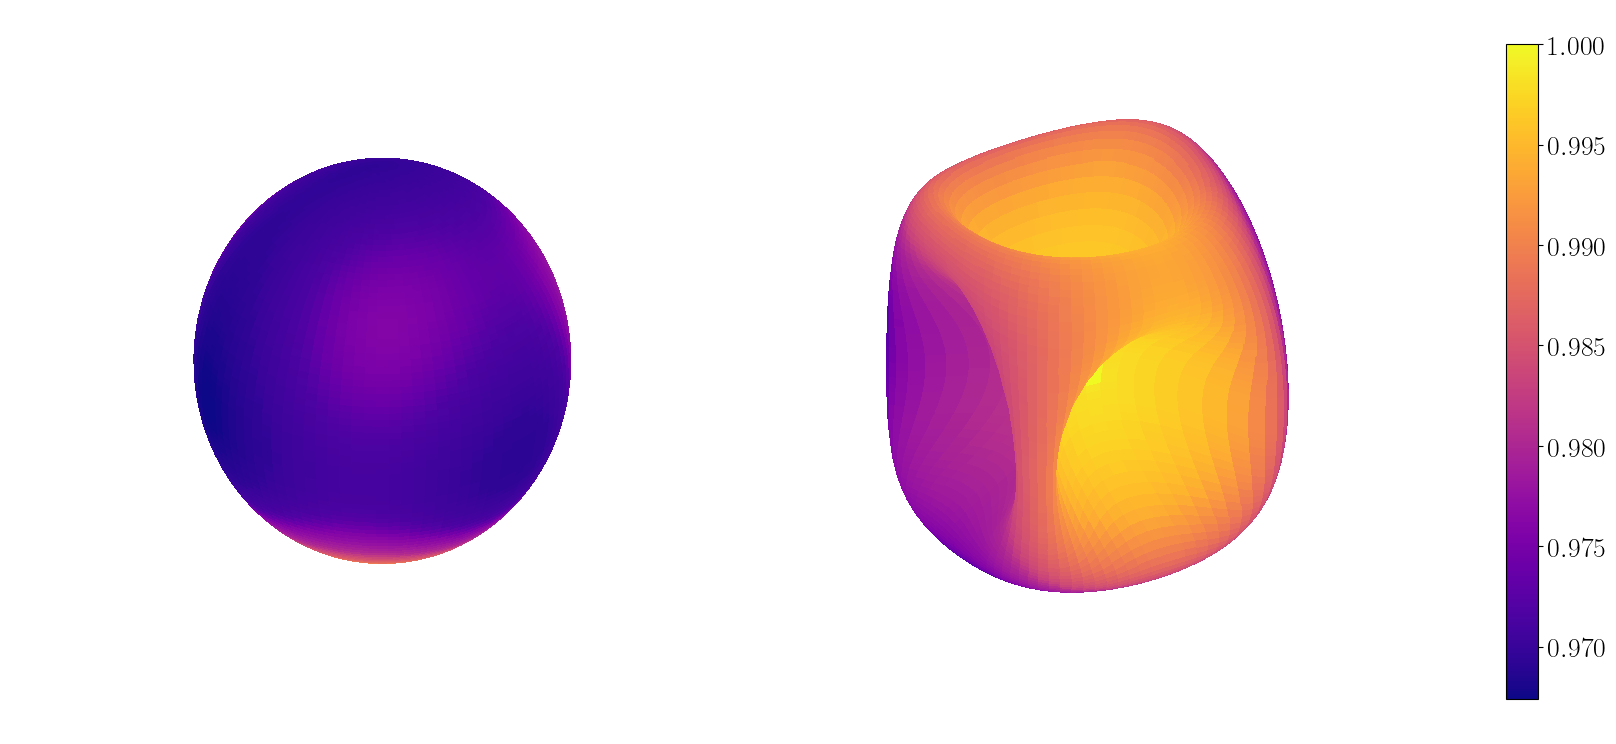

In [17]:
fig = plot_theta_eta_spheres_pyplot(Θx, Θy, Θz, Ηx, Ηy, Ηz, L_matched./norm(L_matched, Inf), "tsp_var_pro_spheres.pdf"; view1=(30,60), view2=(30,60))

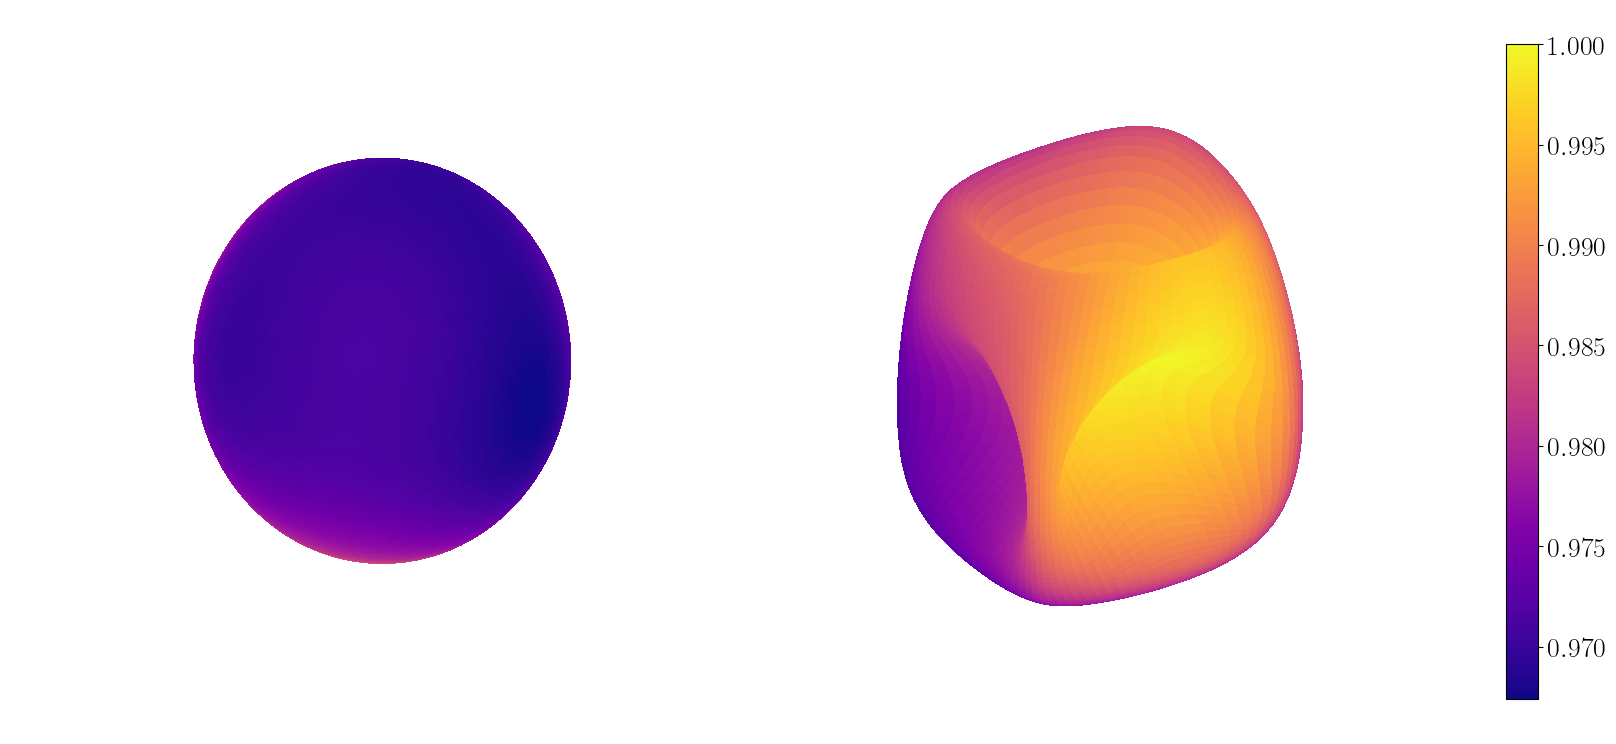

In [18]:
fig = plot_theta_eta_spheres_pyplot(Θx, Θy, Θz, Ηx_noisy, Ηy_noisy, Ηz_noisy, L_noisy./norm(L_noisy, Inf), "tsp_var_pro_spheres_noisy.pdf"; view1=(30,60), view2=(30,60))